# Importando bibliotecas e Dados

## Importação de Dados
Os dados serão importados através do conjunto **dados.csv**, que foi extraído usando o código **Guarda Dados COM**. Os dados são importados sem o nome das colunas, e a primeira coluna é o index.

In [2]:
# importação da biblioteca de dataframes e análise de dados
import pandas as pd
# importação da biblioteca de gráficos
import numpy as np
# importação de biblioteca para manipulação de arquivos
from pathlib import Path
import os
# importação da biblioteca de gráficos
import matplotlib.pyplot as plt
# importação da biblioteca de regressão logística
from sklearn.linear_model import LogisticRegression
# Voting Classifier (Ensenble Learning)
from sklearn.ensemble import VotingClassifier
# Matriz confusão
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, recall_score, f1_score, precision_score

# Importação de Dados

Existem três conjunto de dados ``dados1.csv``, ``dados2.csv``, ``dados3.csv``, ``dados4.csv``, ``dados5.csv`` que foram coletados. Esses conjuntos de dados foram gerados através de simulações do consumo de **bateria** e da **qualidade do sinal**, sendo o último um valor aleatório de qualidade. O intuito de se construir 3 conjuntos de dados para análise, é de que seja possível, em algumas das análises feitas, juntá-los para realizar uma análise do comportamento _"médio"_, ou melhor, do comportamento real do controlador fuzzy. Em algumas análises, ao utilizar apenas um conjunto de dados, como a entrada **qualidade do sinal** é aleatória, pode haver situações em que o comportamento do controlador fuzzy _"real"_ não é traduzido corretamente. Portanto, é necessário integrar os conjuntos em um só, para obter essa análise _"real"_. 

In [3]:
## Dados a serem analisados
DIRETORIO = Path('../Data/fuzzydata')
DATA_FRAMES = []

In [4]:
def load_data (dir):

    """ 
        Lê todos os csv presente no diretório e salva os arquivos em uma lista de dataframes

        dir -> diretório dos dados (type: path)
        dfs -> lista contendo todo o conjunto de dados (type: list)
    """
    
    dfs=[]

    name_columns = [
        'Index', 'Regra1_1', 'Regra1_2', 'Regra1_3', 'Regra1_4', 'Regra2_1', 'Regra2_2', 
        'Regra2_3', 'Regra2_4', 'Regra3_1', 'Regra3_2', 'Regra3_3', 'Regra3_4', 'Regra4_1', 
        'Regra4_2', 'Regra4_3', 'Regra4_4', 'Regra5_1', 'Regra5_2', 'Regra5_3', 'Regra5_4', 
        'Bateria', 'Taxa', 'PertinenciaLiga', 'PertinenciaNaoLiga', 'Saida', 'Class_saida'
    ]

    # Integração dos loops
    for arquivo in dir.glob('*.csv'):
        if arquivo.is_file():
            # O objeto 'arquivo' do pathlib já contém o caminho completo
            # Lemos o CSV e adicionamos diretamente à lista
            df = pd.read_csv(arquivo, header=None, names=name_columns, index_col='Index')
            dfs.append(df)

    print(f"Total de {len(dfs)} arquivos carregados com sucesso.")
    return dfs

In [5]:
DATA_FRAMES = load_data(DIRETORIO)

Total de 5 arquivos carregados com sucesso.


In [15]:
DATA_FRAMES[0].head()

,Regra1_1,Regra1_2,Regra1_3,Regra1_4,Regra2_1,Regra2_2,Regra2_3,Regra2_4,Regra3_1,Regra3_2,...,Regra5_1,Regra5_2,Regra5_3,Regra5_4,Bateria,Taxa,PertinenciaLiga,PertinenciaNaoLiga,Saida,Class_saida
Index,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,100.00,93,1.00,0.0,72.00,1
1,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,99.67,67,0.50,0.0,66.92,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,99.33,29,0.00,1.0,28.00,0
3,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,99.00,74,0.77,0.0,69.98,1
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,98.66,93,1.00,0.0,72.00,1


In [6]:
DATA_FRAMES[0].describe()

,Regra1_1,Regra1_2,Regra1_3,Regra1_4,Regra2_1,Regra2_2,Regra2_3,Regra2_4,Regra3_1,Regra3_2,...,Regra5_1,Regra5_2,Regra5_3,Regra5_4,Bateria,Taxa,PertinenciaLiga,PertinenciaNaoLiga,Saida,Class_saida
count,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,...,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000
mean,0.118243,0.094595,0.033784,0.094595,0.131757,0.104730,0.030405,0.091216,0.162162,0.104730,...,0.209459,0.172297,0.087838,0.141892,50.668919,50.530405,0.449797,0.375608,52.474628,0.567568
std,0.323443,0.293150,0.180978,0.293150,0.338799,0.306723,0.171991,0.288404,0.369224,0.306723,...,0.407612,0.378278,0.283538,0.349530,28.626274,30.440146,0.374805,0.412723,18.940892,0.496253
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.340000,0.000000,0.000000,0.000000,28.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,26.005000,22.000000,0.000000,0.000000,29.982500,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,50.670000,54.000000,0.550000,0.030000,66.920000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,75.335000,77.000000,0.770000,0.792500,69.762500,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,100.000000,96.000000,1.000000,1.000000,72.000000,1.000000


# Análise do Controlador Fuzzy
## Regras de Ativação
Será feito a contagem de ativação das regras que compõem o controlador fuzzy. Essa informação poderá ser útil para identificar regras possivelmente inúteis, equivalentes e sobressalentes.

In [6]:
# Criando DataFrames que contém apenas informações das funções de Ativação do controlador Fuzzy
def data_rules(df):

    """
        Cria lista de dataframes com apenas as colunas referentes à regras de ativação

        df_rules -> lista de dataframe desses conjuntos de dados
        rules_columns -> nomes das colunas eliminadas
    """

    df_rules = []

    rules_columns = ['Bateria','Taxa','PertinenciaLiga','PertinenciaNaoLiga','Saida','Class_saida']

    for data in df:
        df_rules.append(data.drop(rules_columns, axis=1).copy())
    
    return df_rules


In [7]:
DATA_RULES = data_rules(DATA_FRAMES)

def concat_intern_dfs (dfs):
    dfs_c = pd.concat([dfs[0], dfs[1], dfs[2], dfs[3], dfs[4]],ignore_index=True)
    return dfs_c

DATA_RULES_C = concat_intern_dfs(DATA_RULES)

In [9]:
DATA_RULES_C

,Regra1_1,Regra1_2,Regra1_3,Regra1_4,Regra2_1,Regra2_2,Regra2_3,Regra2_4,Regra3_1,Regra3_2,Regra3_3,Regra3_4,Regra4_1,Regra4_2,Regra4_3,Regra4_4,Regra5_1,Regra5_2,Regra5_3,Regra5_4
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1476,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1477,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1478,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


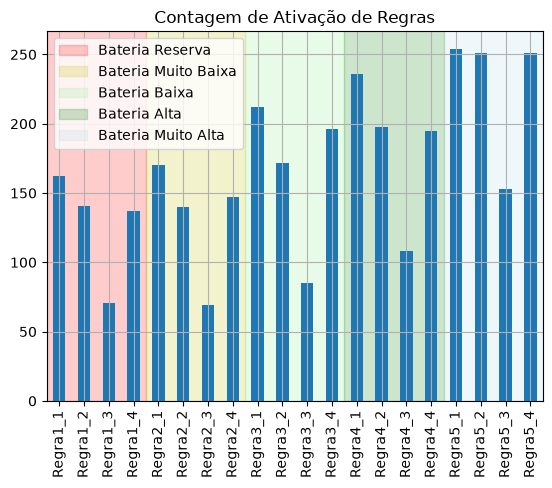

In [8]:
# Soma todas as ativações para cada função
sr_rules_sum = DATA_RULES_C.sum()

# Área do gráfico que representa os estados da bateria
plt.axvspan(-0.5, 3.5, color='red', alpha=0.2, label='Bateria Reserva')
plt.axvspan(3.5, 7.5, color='y', alpha=0.2, label='Bateria Muito Baixa')
plt.axvspan(7.5, 11.5, color='lightgreen', alpha=0.2, label='Bateria Baixa')
plt.axvspan(11.5, 15.5, color='green', alpha=0.2, label='Bateria Alta')
plt.axvspan(15.5, 19.5, color='lightblue', alpha=0.2, label='Bateria Muito Alta')

# Plota o gráfico de barras das funções de ativação
sr_rules_sum.plot(kind='bar',title='Contagem de Ativação de Regras', grid=True)

# Altera a localização da Legenda
plt.legend(loc='upper left', ncol=1)

## Avaliação da Saída do Controlador

In [9]:
# Guarda as colunas que contém a string "Regras"

def data_results(dfs):
    """
        Cria lista de dataframes com apenas as colunas referentes à resultados do controlador Fuzzy

        df_results -> lista de dataframe desses conjuntos de dados
        rules_columns -> nomes das colunas eliminadas
    """
    
    df_results = []

    for data in dfs:
        # Identifica as colunas de regras para cada DataFrame individualmente (mais seguro)
        rules_columns = [col for col in data.columns if col.startswith('Regra')]
        
        # Remove as colunas e adiciona a cópia à lista
        # Note que axis=1 está dentro do drop()
        df_limpo = data.drop(columns=rules_columns).copy()
        df_results.append(df_limpo)
    
    return df_results

In [10]:
DATA_RESULTS_C = concat_intern_dfs(data_results(DATA_FRAMES))

In [53]:
DATA_RESULTS_C

,Bateria,Taxa,PertinenciaLiga,PertinenciaNaoLiga,Saida,Class_saida
0,100.00,93,1.00,0.0,72.00,1
1,99.67,67,0.50,0.0,66.92,1
2,99.33,29,0.00,1.0,28.00,0
3,99.00,74,0.77,0.0,69.98,1
4,98.66,93,1.00,0.0,72.00,1
...,...,...,...,...,...,...
1475,2.68,22,0.00,1.0,28.00,0
1476,2.34,54,0.00,1.0,28.00,0
1477,2.01,16,0.00,1.0,28.00,0
1478,1.67,19,0.00,1.0,28.00,0


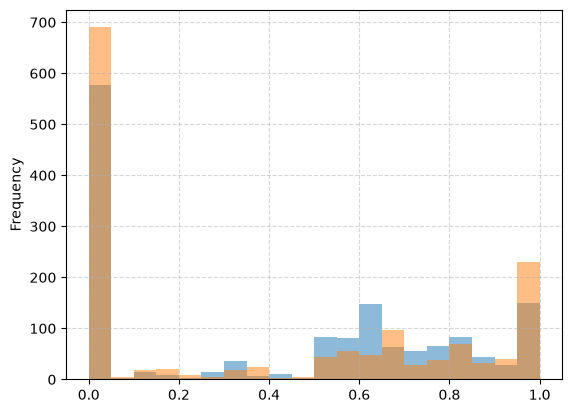

In [11]:
DATA_RESULTS_C['PertinenciaLiga'].plot(kind='hist', bins=20, label='Pertinência Liga', alpha=0.5)
DATA_RESULTS_C['PertinenciaNaoLiga'].plot(kind='hist', bins=20, label='Pertinência Não Liga', alpha=0.5)
plt.grid('on', alpha=0.5, linestyle='--')

O gráfico sugere que existem muitos casos de certezas absolutas no processo de decisão do controlador Fuzzy (valores de pertinência 0 ou 1). Esses casos parecem ser superiores aos casos em que o controlador teve que realizar uma "avaliação" entre pertinências para produzir a saída. Para isso, plota-se o seguinte gráfico adotando:
$$μ = Pertinência_{saída}$$

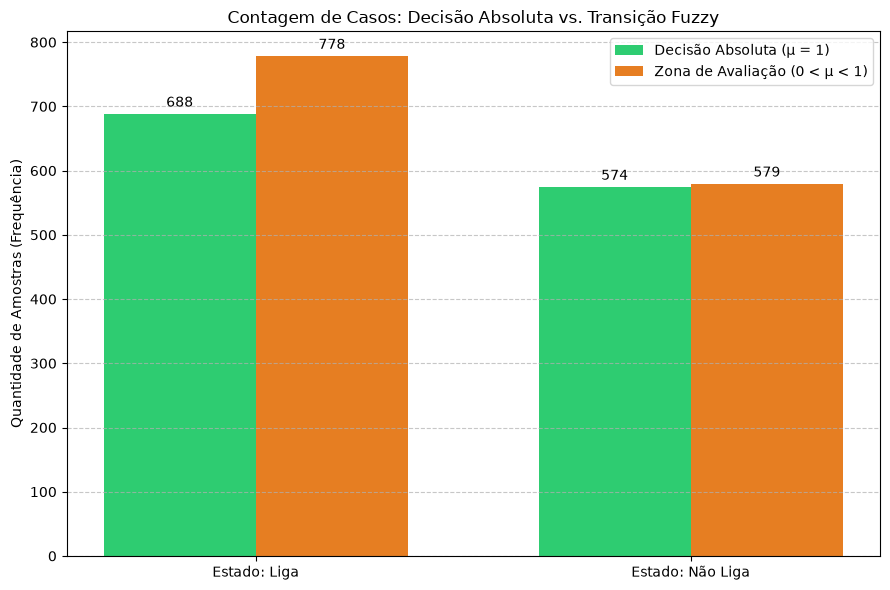

In [12]:
# 1. Calculando a contagem (quantidade de vezes) de cada caso
# Adicionados parênteses para garantir a lógica correta e evitar erros de precedência
abs_liga = DATA_RESULTS_C[(DATA_RESULTS_C['PertinenciaLiga'] == 1) | (DATA_RESULTS_C['PertinenciaNaoLiga'] == 0)].shape[0]
abs_nliga = DATA_RESULTS_C[(DATA_RESULTS_C['PertinenciaNaoLiga'] == 1) | (DATA_RESULTS_C['PertinenciaLiga'] == 0)].shape[0]

# Casos de Transição/Avaliação (Pertinência entre 0 e 1)
aval_liga = DATA_RESULTS_C[(DATA_RESULTS_C['PertinenciaLiga'] > 0) & (DATA_RESULTS_C['PertinenciaLiga'] < 1)].shape[0]
aval_nliga = DATA_RESULTS_C[(DATA_RESULTS_C['PertinenciaNaoLiga'] > 0) & (DATA_RESULTS_C['PertinenciaNaoLiga'] < 1)].shape[0]

# 2. Organização dos dados
labels = ['Estado: Liga', 'Estado: Não Liga']
contagens_absolutas = [abs_liga, abs_nliga]
total_absolutas = sum(contagens_absolutas)

contagens_transicao = [aval_liga, aval_nliga]
total_transicao = sum(contagens_transicao)

x = [0, 1]  # Posições no eixo X
width = 0.35 

# 3. Criação do Gráfico
fig, ax = plt.subplots(figsize=(9, 6))

# Cálculo da posição das barras para ficarem lado a lado corretamente
rects1 = ax.bar([p - width/2 for p in x], contagens_absolutas, width, 
                label='Decisão Absoluta (μ = 1)', color='#2ecc71')
rects2 = ax.bar([p + width/2 for p in x], contagens_transicao, width, 
                label='Zona de Avaliação (0 < μ < 1)', color='#e67e22')

# 4. Customização e Estética
ax.set_ylabel('Quantidade de Amostras (Frequência)')
ax.set_title('Contagem de Casos: Decisão Absoluta vs. Transição Fuzzy')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Adicionando os rótulos numéricos sobre as barras
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
print(f"Porcentagem de Casos Absolutos: {total_absolutas / (total_absolutas + total_transicao) * 100:.2f}%\nPorcentagem de Casos de Transição: {total_transicao / (total_absolutas + total_transicao) * 100:.2f}%")
print(f"Polarização de Decisão: {total_absolutas / total_transicao:.2f}")

Porcentagem de Casos Absolutos: 48.19%
Porcentagem de Casos de Transição: 51.81%
Polarização de Decisão: 0.93


Nota-se que o sistema está muito próximo do equilíbrio entre casos de certeza absoluta e casos de transição (ou avaliação). A métrica `Polarização de Decisão` indica uma característica de decisão do modelo: 

* quanto próxima de `1`, o modelo está equilibrando as decisões absolutas e as avaliações
* quando próxima de `0`, o modelo não possui nenhuma certeza nas decisões
* quando maior que `1`, o modelo está muito confiante na decisão

> Quanto mais equilibrado, melhor o modelo se comporta. Essa métrica pode ser usada similarmente a identificação de casos de underfitting e overfitting de modelos ajustáveis. Nesse caso, indicará se as regras de ativação estão equilibradas em relação aos resultados que se deseja atingir.

## Curva de Taxa de Classificação Fuzzy
Com o intuito de visualizar o comportamento do sistema (ligar ou não ligar o sistema) em relação à bateria, será necessário criar uma taxa usando média ponderada de um intervalo de valores:

$$y_t = \frac{1}{k} \sum_{i=t - \lfloor k/2 \rfloor}^{t + \lfloor k/2 \rfloor} x_i$$

No caso em que $k = 25$:

$$y_t = \frac{x_{t-12} + x_{t-11} + \dots + x_t + \dots + x_{t+11} + x_{t+12}}{25}$$

Esse intervalo deve ser suficientemente grande para produzir uma curva suavizada, e suficientemente pequeno para não aumentar o lag causado pelo cálculo dessa média. O lag é calculado por:

$$Lag = \frac{n - 1}{2}$$

Usando 25 pontos, o Lag será de 12 pontos, mas a curva será suavizada de forma que a visualização do comportamento não seja tão comprometida. O Lag será perceptível nas extremidades do gráfico (ausencia de informação).

Como a o sistema usa a qualidade do sinal para realizar decisões, e essa qualidade é aleatória na simulação, existirá pontos em que a taxa de classificação fuzzy será muito baixa em pontos que poderiam ser altos. Portanto, será necessário usar diversos conjuntos de dados em resposta ao sistema, traçar essas linhas e realizar a média delas. É possível obter mais informações sobre o modelo usando o desvio padrão entre essas linhas.

O desvio padrão demonstra os casos onde o modelo apresenta muita incerteza sobre qual decisão tomar, provavelmente devido a valores de saída em que Liga e Não Liga possuem os mesmos valores.

In [13]:
DATA_RESULTS = data_results(DATA_FRAMES)

In [14]:
# Filtra apenas as colunas Bateria e Saída 
def data_results_BS(data_results_list):
    
    """
        Cria lista de dataframes com apenas as colunas referentes à Bateria e Saída do controlador Fuzzy

        data_results_list -> lista de dataframe desses conjuntos de dados
    """

    for i, df in enumerate(data_results_list):
        data_results_list[i] = df.drop(['Taxa', 'PertinenciaLiga', 'PertinenciaNaoLiga', 'Saida'], axis=1)
    
    return data_results_list

In [15]:
DATA_RESULTS_BS = data_results_BS(DATA_RESULTS)

In [16]:
DATA_RESULTS_BS[0]

,Bateria,Class_saida
Index,,
0,100.00,1
1,99.67,1
2,99.33,0
3,99.00,1
4,98.66,1
...,...,...
291,2.68,0
292,2.34,1
293,2.01,0


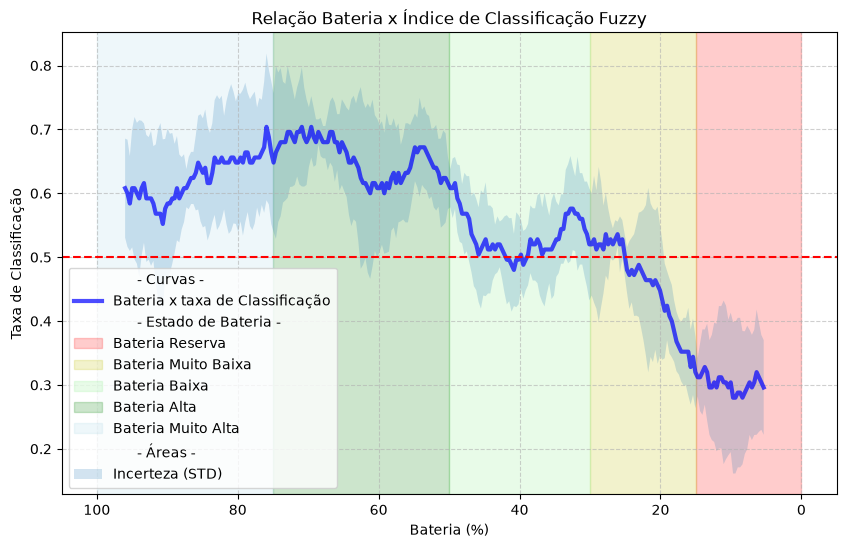

In [17]:
# --- 1. PROCESSAMENTO DOS DADOS ---

# Otimização: Aplicamos a média móvel (rolling) e dropna em todos os DFs da lista via List Comprehension
# Em seguida, já preparamos cada DF para a concatenação (set_index e seleção da coluna alvo)
processed_rates = [
    df.rolling(window=25, center=True).mean()
      .set_index('Bateria')['Class_saida'] 
    for df in DATA_RESULTS_BS
]

# Concatenamos todos os resultados em um único DataFrame (cada DF vira uma coluna)
batery_class_rate_f = pd.concat(processed_rates, axis=1)

# Calculamos as estatísticas por linha (axis=1) para gerar a curva média e a área de sombra
batery_class_rate_f['media'] = batery_class_rate_f.mean(axis=1)
batery_class_rate_f['std'] = batery_class_rate_f.std(axis=1)

# --- 2. PLOTAGEM ---

plt.figure(figsize=(10, 6))

# Títulos decorativos na legenda
plt.plot([], [], ' ', label='      - Curvas -')

# Curva principal (Média)
plt.plot(batery_class_rate_f.index, batery_class_rate_f['media'], 
         label='Bateria x taxa de Classificação', alpha=0.7, color='blue', linewidth=3)

plt.plot([], [], ' ', label='      - Estado de Bateria -')

# Faixas coloridas para estados de bateria
# Nota: axvspan preenche o fundo de acordo com os limites definidos
plt.axvspan(0, 15, color='red', alpha=0.2, label='Bateria Reserva')
plt.axvspan(15, 30, color='y', alpha=0.2, label='Bateria Muito Baixa')
plt.axvspan(30, 50, color='lightgreen', alpha=0.2, label='Bateria Baixa')
plt.axvspan(50, 75, color='green', alpha=0.2, label='Bateria Alta')
plt.axvspan(75, 100, color='lightblue', alpha=0.2, label='Bateria Muito Alta')

plt.plot([], [], ' ', label='      - Áreas -')

# Preenchimento da área de desvio padrão (Incerteza)
plt.fill_between(batery_class_rate_f.index, 
                 batery_class_rate_f['media'] - batery_class_rate_f['std'], 
                 batery_class_rate_f['media'] + batery_class_rate_f['std'], 
                 alpha=0.2, label='Incerteza (STD)')

# Ajustes finos de escala e eixos
plt.gca().invert_xaxis()  # Inverte o eixo X (comum em gráficos de descarga)
plt.title('Relação Bateria x Índice de Classificação Fuzzy')
plt.xlabel('Bateria (%)')
plt.ylabel('Taxa de Classificação')

# Posicionamento da legenda
plt.legend(loc='lower left', ncol=1)

plt.axhline(y=0.5, color='red', linestyle='--', label='Limiar de Decisão')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [21]:
avg_std = batery_class_rate_f['std'].mean()
print(f"Desvio padrão médio: {avg_std:.2f}")

Desvio padrão médio: 0.08


# Machine Learning (Otimização de modelo)

## Transformação do Controlador Fuzzy - Regressão Logística

De certa forma nosso controlador fuzzy funciona como um modelo classificador binário: 0 (Não Liga) ou 1 (Liga). É possível ajustar uma regressão logística para simplificar e otimizar o modelo, possibilitando a integração do mesmo em outras linguagem de programação, sem que haja necessidade de transpor toda a configuração do controlador fuzzy feita. 

## Importação de Bibliotecas para Regressão Logística

In [48]:
# métricas de modelos
from sklearn.metrics import accuracy_score, classification_report, r2_score, brier_score_loss
# pré-processamento
from sklearn.preprocessing import MinMaxScaler

# Importação de modelos de classificação

    ## Modelos não paramétricos
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier

    ## Modelos paramétricos
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import CategoricalNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Bibliotecas extras
from tqdm.auto import tqdm
import m2cgen as m2c

### Split de Dados: Treino e Teste

In [19]:
DATA_RESULTS = data_results(DATA_FRAMES)

def train_split (df_list, df_index):
    """
        Função para separar os dados de treino em x e y

        df_list -> lista de dataframes (type: list)
        df_index -> índice do dataframe a ser usado como validação/teste (type: int)
    """
    X = df_list[df_index][['Bateria', 'Taxa']]
    y = df_list[df_index]['Class_saida']

    return X, y

df_trains = [train_split(DATA_RESULTS, i) for i in range(4)]

df_teste = DATA_RESULTS[4]
X_teste = df_teste[['Bateria', 'Taxa']]
y_teste = df_teste['Class_saida']

## Deifinindo os Modelos

In [31]:
DEC_TREES = [DecisionTreeClassifier(max_depth=10, random_state=42), 
             DecisionTreeClassifier(max_depth=30, random_state=42), 
             DecisionTreeClassifier(max_depth=60, random_state=42),
             DecisionTreeClassifier(max_depth=100, random_state=42)]

LGHT_GBM = [LGBMClassifier(n_estimators=6, verbose=-1, random_state=42),
            LGBMClassifier(n_estimators=12, verbose=-1, random_state=42),
            LGBMClassifier(n_estimators=24, verbose=-1, random_state=42),
            LGBMClassifier(n_estimators=32, verbose=-1, random_state=42)]

RNDM_FRST = [RandomForestClassifier(n_estimators=6, max_depth=3, random_state=42),
             RandomForestClassifier(n_estimators=12, max_depth=4, random_state=42),
             RandomForestClassifier(n_estimators=24, max_depth=5, random_state=42),
             RandomForestClassifier(n_estimators=32, max_depth=6, random_state=42)]

KNN_CLASS = [KNeighborsClassifier(n_neighbors=4),
             KNeighborsClassifier(n_neighbors=8),
             KNeighborsClassifier(n_neighbors=12),
             KNeighborsClassifier(n_neighbors=16)]

NBAY_CLASS = [CategoricalNB(alpha=0.2),
             CategoricalNB(alpha=0.5),
             CategoricalNB(alpha=0.8),
             CategoricalNB(alpha=1)]

LOG_REGS = [LogisticRegression(max_iter=100),
            LogisticRegression(max_iter=200), 
            LogisticRegression(max_iter=300), 
            LogisticRegression(max_iter=400)]

SVM_CLASS = [SVC(kernel="rbf", C=0.01, gamma="scale", probability=True, random_state=42),
             SVC(kernel="rbf", C=0.1, gamma="scale", probability=True, random_state=42),
             SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42),
             SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42)]

NEUR_CLASS = [MLPClassifier(hidden_layer_sizes=(12,12), activation='relu', solver='adam', max_iter=1000, random_state=42),
              MLPClassifier(hidden_layer_sizes=(18,18), activation='relu', solver='adam', max_iter=1000, random_state=42),
              MLPClassifier(hidden_layer_sizes=(24,24), activation='relu', solver='adam', max_iter=1000, random_state=42),
              MLPClassifier(hidden_layer_sizes=(32,32), activation='relu', solver='adam', max_iter=1000, random_state=42)]

QDA_CLASS = [QuadraticDiscriminantAnalysis(reg_param=0.0),
             QuadraticDiscriminantAnalysis(reg_param=0.01),
             QuadraticDiscriminantAnalysis(reg_param=0.1),
             QuadraticDiscriminantAnalysis(reg_param=1.0)]

In [32]:
def train_models (df_trains, models, tqdm):

    trained_models = []
    reports = []

    for j in range(len(models)):
        for i, (X_train, y_train) in enumerate(df_trains):
            trained_model = models[j].fit(X_train, y_train)
            trained_models.append(trained_model)

            # Avaliação do modelo no conjunto de teste
            y_pred = trained_model.predict(X_teste)
            class_report = classification_report(y_teste, y_pred, output_dict=True)['0']
            r2 = r2_score(y_teste, y_pred)
            class_report['r2_score'] = r2
            reports.append(class_report)
            tqdm.update(1)

    return trained_models, reports


In [33]:
with tqdm(total=144, desc="Cronograma de Treinamento Geral") as pbar:

    pbar.set_postfix_str("Rodando: LOG_REGS")
    TRAINNED_LOG_REGS, TRAINNED_LOG_REGS_REPORT = train_models(df_trains, LOG_REGS, pbar)

    pbar.set_postfix_str("Rodando: DEC_TREES")
    TRAINNED_DEC_TREES, TRAINNED_DEC_TREES_REPORT = train_models(df_trains, DEC_TREES, pbar)

    pbar.set_postfix_str("Rodando: LGHT_GBM")
    TRAINNED_LGHT_GBM, TRAINNED_LGHT_GBM_REPORT = train_models(df_trains, LGHT_GBM, pbar)

    pbar.set_postfix_str("Rodando: RNDM_FRST")
    TRAINNED_RNDM_FRST, TRAINNED_RNDM_FRST_REPORT = train_models(df_trains, RNDM_FRST, pbar)

    pbar.set_postfix_str("Rodando: KNN_CLASS")
    TRAINNED_KNN_CLASS, TRAINNED_KNN_CLASS_REPORT = train_models(df_trains, KNN_CLASS, pbar)
    
    pbar.set_postfix_str("Rodando: NBAY_CLASS")
    TRAINNED_NBAY_CLASS, TRAINNED_NBAY_CLASS_REPORT = train_models(df_trains, NBAY_CLASS, pbar)

    pbar.set_postfix_str("Rodando: SVM_CLASS")
    TRAINNED_SVM_CLASS, TRAINNED_SVM_CLASS_REPORT = train_models(df_trains, SVM_CLASS, pbar)

    pbar.set_postfix_str("Rodando: NEUR_CLASS")
    TRAINNED_NEUR_CLASS, TRAINNED_NEUR_CLASS_REPORT = train_models(df_trains, NEUR_CLASS, pbar)

    pbar.set_postfix_str("Rodando: QDA_CLASS")
    TRAINNED_QDA_CLASS, TRAINNED_QDA_CLASS_REPORT = train_models(df_trains, QDA_CLASS, pbar)

Cronograma de Treinamento Geral:   0%|          | 0/144 [00:00<?, ?it/s]

d:\Projetos\Simulador-IA\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Projetos\Simulador-IA\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Projetos\Simulador-IA\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Projetos\Simulador-IA\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be remov

In [34]:
def gerar_tabela_metricas_completa(relatorios_agrupados):
    """
    relatorios_agrupados -> dicionário onde a chave é o nome do grupo 
                            e o valor é a LISTA de relatórios retornada pelas funções.
    """
    dados_tabela = []
    
    for nome_grupo, lista_reports in relatorios_agrupados.items():
        for i, report in enumerate(lista_reports):
            linha = {
                "Grupo": nome_grupo,
                "Modelo_ID": i, # Índice do modelo dentro da lista
                "Precision": report.get("precision"),
                "Recall": report.get("recall"),
                "F1-Score": report.get("f1-score"),
                "Support": report.get("support"),
                "R2": report.get("r2_score")
            }
            dados_tabela.append(linha)
            
    return pd.DataFrame(dados_tabela)

In [35]:
# Agora que as funções retornam listas:
relatorios_totais = {
    "REG_MODEL": TRAINNED_LOG_REGS_REPORT,
    "DEC_MODEL": TRAINNED_DEC_TREES_REPORT,
    "LGB_MODEL": TRAINNED_LGHT_GBM_REPORT,
    "RFR_MODEL": TRAINNED_RNDM_FRST_REPORT,
    "KNN_MODEL": TRAINNED_KNN_CLASS_REPORT,
    "NBA_MODEL": TRAINNED_NBAY_CLASS_REPORT,
    "SVM_MODEL": TRAINNED_SVM_CLASS_REPORT,
    "NNW_MODEL": TRAINNED_NEUR_CLASS_REPORT,
    "QDA_MODEL": TRAINNED_QDA_CLASS_REPORT
}

# Gera a tabela detalhada com todos os modelos
df_completo = gerar_tabela_metricas_completa(relatorios_totais)
display(df_completo)

,Grupo,Modelo_ID,Precision,Recall,F1-Score,Support,R2
0,REG_MODEL,0,0.958904,0.985915,0.972222,142.0,0.891714
1,REG_MODEL,1,0.965035,0.971831,0.968421,142.0,0.878178
2,REG_MODEL,2,0.958042,0.964789,0.961404,142.0,0.851107
3,REG_MODEL,3,0.977941,0.936620,0.956835,142.0,0.837571
4,REG_MODEL,4,0.958904,0.985915,0.972222,142.0,0.891714
...,...,...,...,...,...,...,...
139,QDA_MODEL,11,0.985075,0.929577,0.956522,142.0,0.837571
140,QDA_MODEL,12,0.925676,0.964789,0.944828,142.0,0.783428
141,QDA_MODEL,13,0.923611,0.936620,0.930070,142.0,0.729285
142,QDA_MODEL,14,0.945946,0.985915,0.965517,142.0,0.864642


In [36]:
def selecionar_melhores_modelos(
    df_metricas, 
    dicionario_modelos_treinados, 
    metricas=["F1-Score", "Precision", "Recall"], 
    pesos=None
):
    """
    Seleciona o melhor modelo de cada grupo com base em múltiplas métricas 
    através de um score composto.
    
    Parameters:
    -----------
    df_metricas : pd.DataFrame
        DataFrame contendo 'Grupo', 'Modelo_ID' e as colunas de métricas.
    dicionario_modelos_treinados : dict
        Dicionário onde a chave é o nome do grupo e o valor é a LISTA de modelos.
    metricas : list of str
        Lista com os nomes das colunas de métricas a serem consideradas.
    pesos : dict or list, optional
        Pesos para cada métrica. Se None, todas as métricas têm o mesmo peso (1.0).
        Exemplo: {"F1-Score": 0.5, "Precision": 0.3, "Recall": 0.2}
    """
    melhores_modelos = {}
    df_temp = df_metricas.copy()
    
    # 1. Validação e tratamento dos pesos
    if pesos is None:
        # Pesos iguais para todas as métricas passadas
        pesos_dict = {m: 1.0 for m in metricas}
    elif isinstance(pesos, list):
        pesos_dict = dict(zip(metricas, pesos))
    else:
        pesos_dict = pesos

    # 2. Cálculo do Score Composto
    # Garante a soma ponderada das métricas especificadas
    score_col = np.zeros(len(df_temp))
    soma_pesos = sum(pesos_dict[m] for m in metricas)

    for m in metricas:
        score_col += df_temp[m] * pesos_dict[m]
    
    df_temp["Score_Composto"] = score_col / soma_pesos

    # 3. Seleção do melhor modelo por grupo
    for grupo, grupo_df in df_temp.groupby("Grupo"):
        # Encontra o índice da linha com maior Score Composto
        melhor_linha = grupo_df.loc[grupo_df["Score_Composto"].idxmax()]
        melhor_idx = int(melhor_linha["Modelo_ID"])
        
        # Resgata o objeto do modelo
        melhores_modelos[grupo] = dicionario_modelos_treinados[grupo][melhor_idx]
        
        # Exibição detalhada dos resultados selecionados
        valores_metricas_str = ", ".join([f"{m}: {melhor_linha[m]:.4f}" for m in metricas])
        print(f"[{grupo}] Melhor Modelo ID {melhor_idx} | Score Composto: {melhor_linha['Score_Composto']:.4f} ({valores_metricas_str})")
        
    return melhores_modelos

In [81]:
# 1. Agrupa os modelos treinados em um dicionário
todos_os_modelos_treinados = {
    "REG_MODEL": TRAINNED_LOG_REGS,
    "DEC_MODEL": TRAINNED_DEC_TREES,
    "LGB_MODEL": TRAINNED_LGHT_GBM,
    "RFR_MODEL": TRAINNED_RNDM_FRST,
    "KNN_MODEL": TRAINNED_KNN_CLASS,
    "NBA_MODEL": TRAINNED_NBAY_CLASS,
    "SVM_MODEL": TRAINNED_SVM_CLASS,
    "NNW_MODEL": TRAINNED_NEUR_CLASS,
    "QDA_MODEL": TRAINNED_QDA_CLASS
}
# 3. Define pesos de prioridade às métricas avaliadas 
meus_pesos = {
    "F1-Score": 0.15,
    "Accuracy": 0.2,
    "Precision": 0.15,
    "R2": 0.5
}

# 2. Executa a função escolhendo a métrica de referência (ex: "F1-Score")
dict_melhores_modelos = selecionar_melhores_modelos(
    df_completo, 
    todos_os_modelos_treinados, 
    metricas=["F1-Score", "Precision", "Recall", "R2"]
)

KeyError: 'F1-Score'

In [38]:
list_melhores_modelos_teste_metricas = [] # Abreviado para mmtm

for key in dict_melhores_modelos:
    y_pred = dict_melhores_modelos[key].predict(X_teste)
    list_melhores_modelos_teste_metricas.append({"acc": accuracy_score(y_teste, y_pred),
                                                 "prec": precision_score(y_teste, y_pred),
                                                 "rec": recall_score(y_teste, y_pred),
                                                 "f1": f1_score(y_teste, y_pred),
                                                 "r2": r2_score(y_teste, y_pred),
                                                 "model": key})
df_mmtm = pd.DataFrame(list_melhores_modelos_teste_metricas)
df_mmtm[["model", "acc", "prec", "rec", "f1", "r2"]]

,model,acc,prec,rec,f1,r2
0,DEC_MODEL,0.986486,0.993421,0.980519,0.986928,0.945857
1,KNN_MODEL,0.969595,0.961783,0.980519,0.971061,0.878178
2,LGB_MODEL,0.993243,0.987179,1.000000,0.993548,0.972928
3,NBA_MODEL,0.895270,0.901961,0.896104,0.899023,0.580391
4,NNW_MODEL,0.966216,0.939024,1.000000,0.968553,0.864642
5,QDA_MODEL,0.972973,0.956250,0.993506,0.974522,0.891714
6,REG_MODEL,0.959459,0.943750,0.980519,0.961783,0.837571
7,RFR_MODEL,0.989865,0.980892,1.000000,0.990354,0.959393
8,SVM_MODEL,0.966216,0.955696,0.980519,0.967949,0.864642


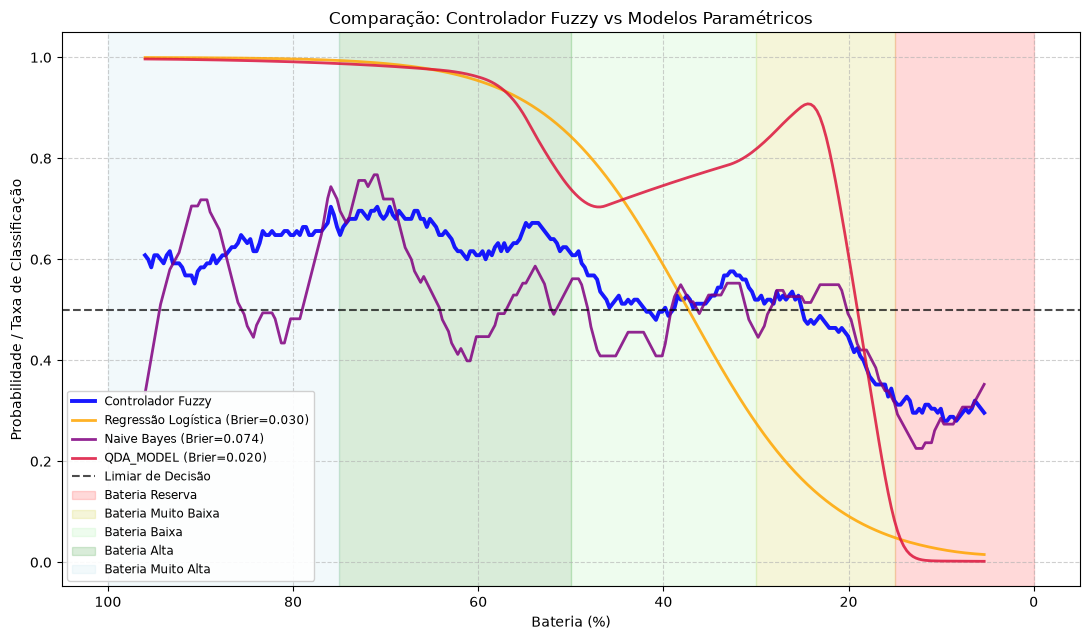

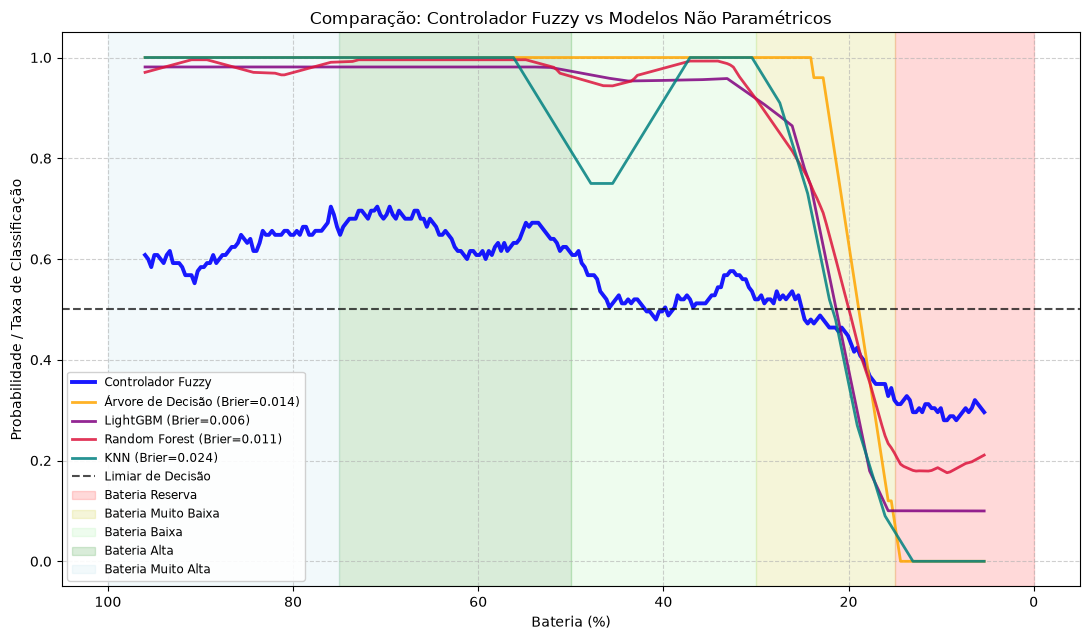

In [49]:
# --- 1. Alinhamento de Grid e Tratamento Anti-NaN ---
if 'taxa_media' not in locals():
    taxa_media = pd.concat([df[['Taxa']] for df in DATA_RESULTS], ignore_index=True)['Taxa'].mean()

bateria_index = batery_class_rate_f.index

X_grid = pd.DataFrame({
    'Bateria': bateria_index,
    'Taxa': taxa_media
}).ffill().bfill().fillna(0)

X_teste_clean = pd.DataFrame(X_teste).ffill().bfill().fillna(0)

# Mapeamento e categorização dos modelos
NOMES_LEGIVEIS = {
    "REG_MODEL": "Regressão Logística",
    "DEC_MODEL": "Árvore de Decisão",
    "LGB_MODEL": "LightGBM",
    "RFR_MODEL": "Random Forest",
    "KNN_MODEL": "KNN",
    "NBA_MODEL": "Naive Bayes"
}

GRUPOS_MODELOS = {
    "Paramétricos": ["REG_MODEL", "NBA_MODEL", "QDA_MODEL"],
    "Não Paramétricos": ["DEC_MODEL", "LGB_MODEL", "RFR_MODEL", "KNN_MODEL"]
}

paleta_cores = ['orange', 'purple', 'crimson', 'teal', 'green', 'brown']

# --- 2. Função de Plotagem Personalizada ---
def plotar_comparacao_fuzzy(chaves_modelos, titulo_grafico):
    plt.figure(figsize=(11, 6.5))

    # Baseline: Controlador Fuzzy
    plt.plot(
        batery_class_rate_f.index, 
        batery_class_rate_f['media'],
        label='Controlador Fuzzy', 
        color='blue', 
        linewidth=2.8, 
        alpha=0.9
    )

    # Iteração apenas nos modelos do grupo selecionado
    for idx, chave_grupo in enumerate(chaves_modelos):
        if chave_grupo not in dict_melhores_modelos:
            continue
            
        modelo = dict_melhores_modelos[chave_grupo]
        nome_modelo = NOMES_LEGIVEIS.get(chave_grupo, chave_grupo)

        # Predição com fallback seguro
        if hasattr(modelo, "predict_proba"):
            probs_grid_raw = modelo.predict_proba(X_grid)[:, 1]
            probs_teste = modelo.predict_proba(X_teste_clean)[:, 1]
        elif hasattr(modelo, "decision_function"):
            dec_grid = modelo.decision_function(X_grid)
            dec_teste = modelo.decision_function(X_teste_clean)
            scaler = MinMaxScaler()
            probs_grid_raw = scaler.fit_transform(dec_grid.reshape(-1, 1)).ravel()
            probs_teste = scaler.fit_transform(dec_teste.reshape(-1, 1)).ravel()
        else:
            probs_grid_raw = modelo.predict(X_grid)
            probs_teste = modelo.predict(X_teste_clean)

        brier = brier_score_loss(y_teste, probs_teste)

        # Suavização por Média Móvel
        probs_suaves = (
            pd.Series(probs_grid_raw, index=bateria_index)
            .rolling(window=25, center=True, min_periods=1)
            .mean()
        )

        plt.plot(
            bateria_index, 
            probs_suaves,
            label=f'{nome_modelo} (Brier={brier:.3f})', 
            color=paleta_cores[idx % len(paleta_cores)], 
            linewidth=2.0, 
            alpha=0.85
        )

    # Marcadores e faixas de estado de bateria
    plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.7, label='Limiar de Decisão')
    plt.axvspan(0, 15, color='red', alpha=0.15, label='Bateria Reserva')
    plt.axvspan(15, 30, color='y', alpha=0.15, label='Bateria Muito Baixa')
    plt.axvspan(30, 50, color='lightgreen', alpha=0.15, label='Bateria Baixa')
    plt.axvspan(50, 75, color='green', alpha=0.15, label='Bateria Alta')
    plt.axvspan(75, 100, color='lightblue', alpha=0.15, label='Bateria Muito Alta')

    plt.gca().invert_xaxis()
    plt.title(titulo_grafico)
    plt.xlabel('Bateria (%)')
    plt.ylabel('Probabilidade / Taxa de Classificação')
    plt.legend(loc='lower left', bbox_to_anchor=(0, 0), fontsize='small', framealpha=0.9)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- 3. Geração dos Dois Gráficos ---

# Gráfico 1: Modelos Paramétricos vs Fuzzy
plotar_comparacao_fuzzy(
    GRUPOS_MODELOS["Paramétricos"], 
    'Comparação: Controlador Fuzzy vs Modelos Paramétricos'
)

# Gráfico 2: Modelos Não Paramétricos vs Fuzzy
plotar_comparacao_fuzzy(
    GRUPOS_MODELOS["Não Paramétricos"], 
    'Comparação: Controlador Fuzzy vs Modelos Não Paramétricos'
)

In [66]:
def plot_dispersao_fronteira(modelo, df_dados, col_bateria='Bateria', col_taxa='Taxa', col_alvo='Estado', titulo_modelo=None, ax=None):
    """
    Gera um gráfico de dispersão (Bateria vs Taxa) colorido pela classe real, 
    sobreposto pela fronteira de decisão (probabilidade bruta) do modelo em um subplot (ax).
    """
    if ax is None:
        ax = plt.gca()

    # Tratamento de NaN e preparação das variáveis
    df_clean = df_dados[[col_bateria, col_taxa, col_alvo]].dropna()
    X = df_clean[[col_bateria, col_taxa]]
    y = df_clean[col_alvo]

    # Construção da grade respeitando estritamente os limites
    x_min, x_max = X[col_bateria].min(), X[col_bateria].max()
    y_min, y_max = X[col_taxa].min(), X[col_taxa].max()
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    
    grid_points = pd.DataFrame({col_bateria: xx.ravel(), col_taxa: yy.ravel()})[X.columns]

    # Predição na grade com tratamento de fallback
    try:
        if hasattr(modelo, "predict_proba"):
            Z = modelo.predict_proba(grid_points)[:, 1]
        elif hasattr(modelo, "decision_function"):
            Z = modelo.decision_function(grid_points)
        else:
            Z = modelo.predict(grid_points)
    except Exception:
        Z = modelo.predict(grid_points)
        
    Z = Z.reshape(xx.shape)

    # Plotagem direta no eixo `ax`
    contour = ax.contourf(xx, yy, Z, levels=20, cmap='RdYlBu_r', alpha=0.3)
    
    # Adiciona colorbar no eixo correspondente
    plt.colorbar(contour, ax=ax, fraction=0.046, pad=0.04)

    # Fronteira de decisão (50%)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--', linewidths=1.5)

    # Dispersão das amostras
    scatter = ax.scatter(
        X[col_bateria], 
        X[col_taxa], 
        c=y, 
        cmap='coolwarm', 
        edgecolors='k', 
        linewidth=0.3, 
        s=25, 
        alpha=0.85
    )

    handles, _ = scatter.legend_elements()
    ax.legend(handles, ['Classe 0', 'Classe 1'], loc='upper right', title='Estado', fontsize='x-small')

    nome = titulo_modelo if titulo_modelo else type(modelo).__name__
    ax.set_title(f'Fronteira: {nome}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Bateria (%)', fontsize=8)
    ax.set_ylabel('Taxa', fontsize=8)
    
    ax.invert_xaxis()
    ax.grid(True, linestyle='--', alpha=0.5)

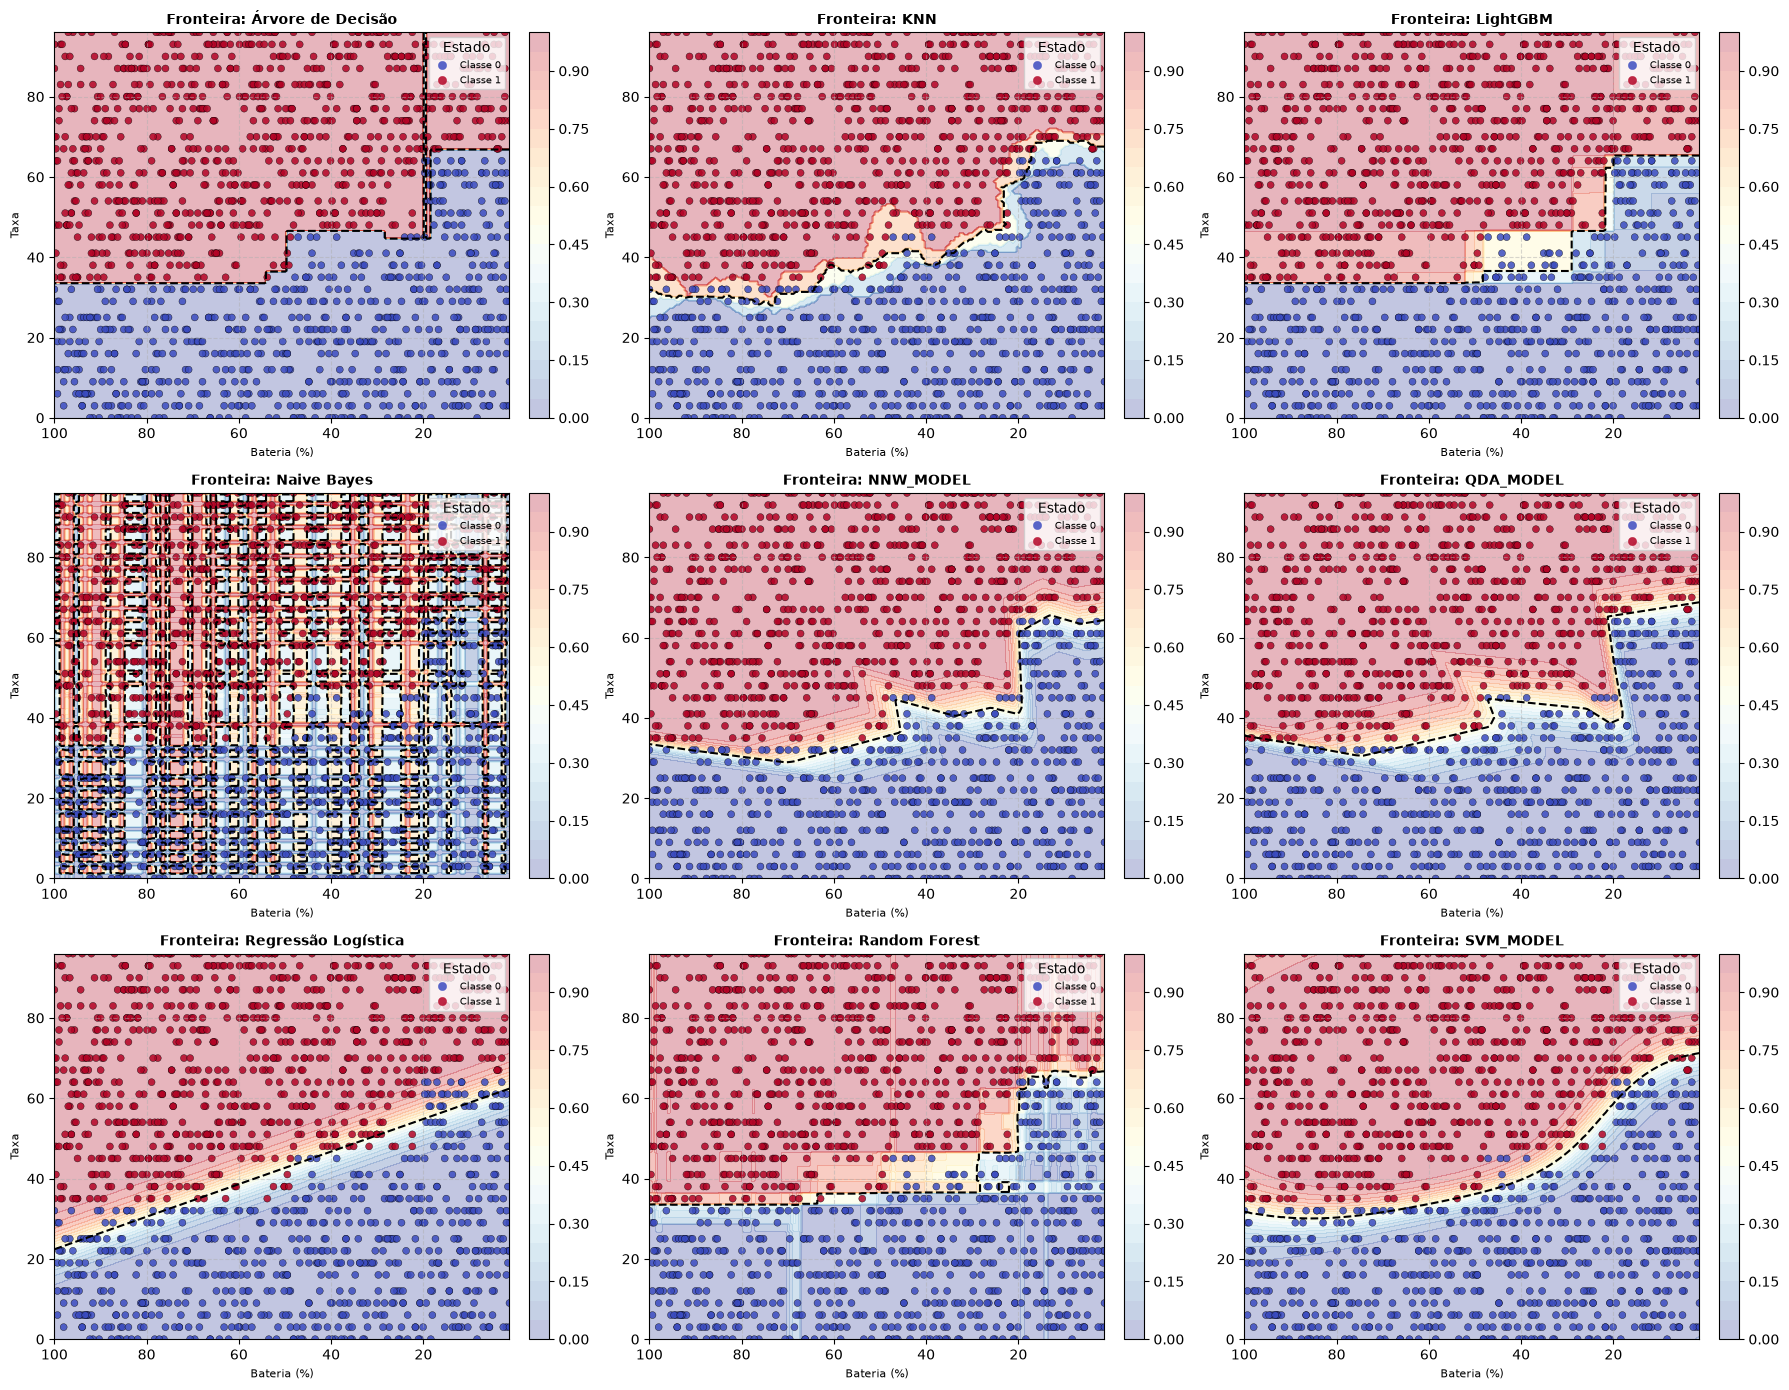

In [67]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes_flat = axes.flatten()

for ax, (chave, modelo) in zip(axes_flat, dict_melhores_modelos.items()):
    nome_exibicao = NOMES_LEGIVEIS.get(chave, chave)
    
    plot_dispersao_fronteira(
        modelo=modelo,
        df_dados=DATA_RESULTS_C,
        col_bateria='Bateria',
        col_taxa='Taxa',
        col_alvo='Class_saida', # Ajuste para o nome da sua coluna target
        titulo_modelo=nome_exibicao,
        ax=ax
    )

# Oculta eixos remanescentes caso haja menos de 9 modelos
for i in range(len(dict_melhores_modelos), len(axes_flat)):
    fig.delaxes(axes_flat[i])

plt.tight_layout()
plt.show()

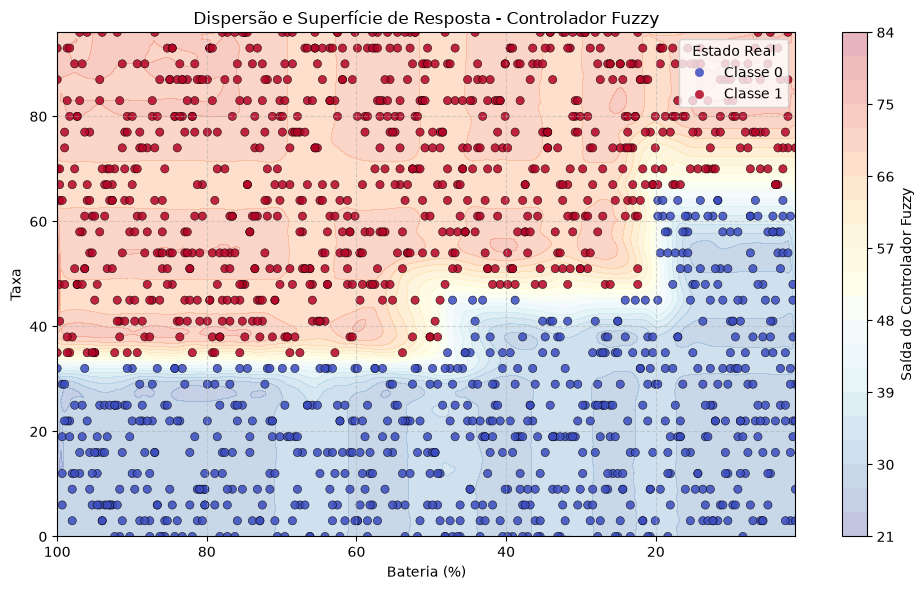

In [74]:
from scipy.interpolate import griddata

def plot_dispersao_fuzzy(df_fuzzy, col_bateria='Bateria', col_taxa='Taxa', col_saida='Taxa_Fuzzy', col_alvo='Estado'):
    """
    Gera o gráfico de dispersão (Bateria vs Taxa) com a superfície contínua
    e a fronteira do Controlador Fuzzy a partir de DATA_RESULTS_c.
    """
    df_clean = df_fuzzy[[col_bateria, col_taxa, col_saida, col_alvo]].dropna()
    
    X = df_clean[col_bateria]
    Y = df_clean[col_taxa]
    Z_fuzzy = df_clean[col_saida]
    y_estado = df_clean[col_alvo]

    # 1. Criação do Grid para a superfície contínua
    xi = np.linspace(X.min(), X.max(), 200)
    yi = np.linspace(Y.min(), Y.max(), 200)
    xx, yy = np.meshgrid(xi, yi)

    # 2. Interpolação das saídas do Fuzzy nos pontos do grid (método cúbico)
    zz = griddata((X, Y), Z_fuzzy, (xx, yy), method='cubic')
    
    # Preenche eventuais pontos fora da cobertura com interpolação vizinho mais próximo
    if np.isnan(zz).any():
        zz_nearest = griddata((X, Y), Z_fuzzy, (xx, yy), method='nearest')
        zz = np.where(np.isnan(zz), zz_nearest, zz)

    # 3. Plotagem
    plt.figure(figsize=(10, 6))

    # Superfície de resposta contínua do Fuzzy
    contour = plt.contourf(xx, yy, zz, levels=20, cmap='RdYlBu_r', alpha=0.3)
    cbar = plt.colorbar(contour)
    cbar.set_label('Saída do Controlador Fuzzy')

    # Limiar / Fronteira de Decisão de 0.5 (50%)
    plt.contour(xx, yy, zz, levels=[0.5], colors='black', linestyles='--', linewidths=2)

    # Pontos de Dispersão das Amostras
    scatter = plt.scatter(
        X, Y, 
        c=y_estado, 
        cmap='coolwarm', 
        edgecolors='k', 
        linewidth=0.4, 
        s=35, 
        alpha=0.85
    )

    # Configurações do Gráfico
    handles, _ = scatter.legend_elements()
    plt.legend(handles, ['Classe 0', 'Classe 1'], loc='upper right', title='Estado Real')

    plt.title('Dispersão e Superfície de Resposta - Controlador Fuzzy')
    plt.xlabel('Bateria (%)')
    plt.ylabel('Taxa')
    plt.gca().invert_xaxis()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# --- Execução ---

plot_dispersao_fuzzy(
    df_fuzzy=DATA_RESULTS_C,
    col_bateria='Bateria',
    col_taxa='Taxa',
    col_saida='Saida', # Ajuste para o nome da coluna de saída do controlador no seu DF
    col_alvo='Class_saida'        # Ajuste para o nome da sua coluna de estado real
)

| Árvore de Decisão | Accuracy: 0.9865 |
| KNN | Accuracy: 0.9696 |
| LightGBM | Accuracy: 0.9932 |
| Naive Bayes | Accuracy: 0.8953 |
| NNW_MODEL | Accuracy: 0.9662 |
| QDA_MODEL | Accuracy: 0.9730 |
| Regressão Logística | Accuracy: 0.9595 |
| Random Forest | Accuracy: 0.9899 |
| SVM_MODEL | Accuracy: 0.9662 |


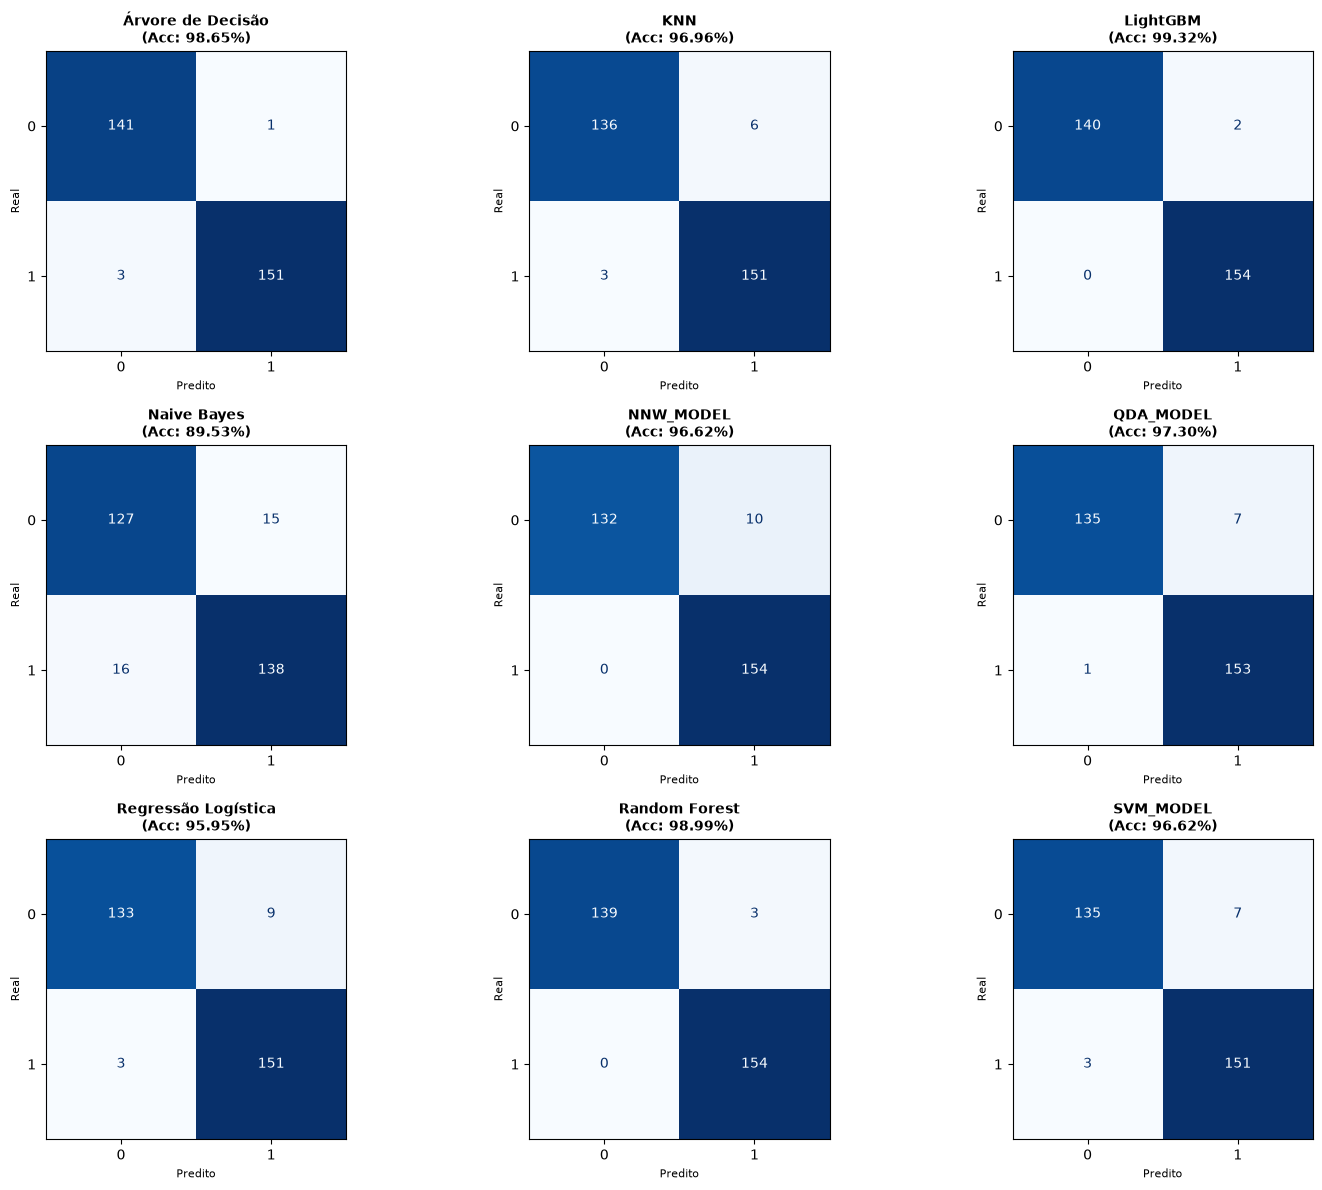

In [78]:
# 1. Ajuste das dimensões da figura (3x3 precisa de mais altura do que 14x6)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes_flat = axes.flatten()  # Achata a matriz 3x3 para uma lista de 9 eixos

# 2. Iteração unificada sobre os eixos e o dicionário dict_melhores_modelos
for ax, (chave, modelo) in zip(axes_flat, dict_melhores_modelos.items()):
    nome_exibicao = NOMES_LEGIVEIS.get(chave, chave)
    
    # Realiza a predição no conjunto de teste
    y_pred = modelo.predict(X_teste)
    
    # Calcula a matriz de confusão e a acurácia
    cm = confusion_matrix(y_teste, y_pred)
    accuracy = accuracy_score(y_teste, y_pred)
    
    # Exibe no console
    print(f"| {nome_exibicao} |", end='')
    print(f" Accuracy: {accuracy:.4f} |")
    
    # Configura a exibição da matriz no subplot atual
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=getattr(modelo, 'classes_', None)
    )
    
    # Plotagem direta no eixo `ax`
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    
    ax.set_title(f'{nome_exibicao}\n(Acc: {accuracy:.2%})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predito', fontsize=8)
    ax.set_ylabel('Real', fontsize=8)

# 3. Oculta eixos sobressalentes caso haja menos de 9 modelos no dicionário
for i in range(len(dict_melhores_modelos), len(axes_flat)):
    fig.delaxes(axes_flat[i])

plt.tight_layout()
plt.show()

# Convertendo Modelos para uso na STM32

In [ ]:
import os
import m2cgen as m2c
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# 1. Configuração de Diretórios de Destino
PASTA_SRC = "../Stm32-Nucleo/Core/Src"
PASTA_ONNX = "./modelos_onnx"

os.makedirs(PASTA_SRC, exist_ok=True)
os.makedirs(PASTA_ONNX, exist_ok=True)

print("=== INICIANDO EXPORTAÇÃO DE MODELOS ===\n")

# 2. Loop de Processamento do Dicionário
for chave, modelo in dict_melhores_modelos.items():
    nome_base = chave.lower()
    
    # --- CASO ESPECIAL: KNN ---
    if "KNN" in chave.upper():
        print(f"⚠️  [{chave}] Algoritmo de memória bruta. Ignorado para exportação C direta.")
        continue

    # --- TENTATIVA 1: m2cgen (Gera apenas o arquivo .c) ---
    try:
        codigo_c = m2c.export_to_c(modelo, function_name=f"predict_{nome_base}")
        caminho_c = os.path.join(PASTA_SRC, f"{nome_base}.c")
        
        with open(caminho_c, "w") as f:
            f.write(codigo_c)
            
        print(f"✔ [m2cgen] Código C gerado: {nome_base}.c")
        continue
    except Exception:
        # Se falhar (ex: Naive Bayes, MLP, QDA), segue para geração do ONNX
        pass

    # --- TENTATIVA 2: skl2onnx (Gera apenas o arquivo .onnx) ---
    try:
        initial_type = [('float_input', FloatTensorType([None, 2]))]
        onnx_model = convert_sklearn(modelo, initial_types=initial_type, target_opset=12)
        
        caminho_onnx = os.path.join(PASTA_ONNX, f"{nome_base}.onnx")
        with open(caminho_onnx, "wb") as f:
            f.write(onnx_model.SerializeToString())
            
        print(f"📦 [ONNX] Modelo ONNX gerado: {nome_base}.onnx")
    except Exception as err:
        print(f"❌ Erro ao exportar {chave}: {err}")

print("\n=== PROCESSO CONCLUÍDO ===")

=== INICIANDO PIPELINE DE CONVERSÃO PARA STM32 ===

✔ [m2cgen] Exportado com sucesso: dec_model.c
⚠️  [KNN_MODEL] Algoritmo de memória bruta. Recomendado exportar matriz estática de treino.
✔ [m2cgen] Exportado com sucesso: lgb_model.c
📦 [ONNX] Exportado modelo ONNX: nba_model.onnx (Pronto para STM32Cube.AI CLI)
📦 [ONNX] Exportado modelo ONNX: nnw_model.onnx (Pronto para STM32Cube.AI CLI)
📦 [ONNX] Exportado modelo ONNX: qda_model.onnx (Pronto para STM32Cube.AI CLI)
✔ [m2cgen] Exportado com sucesso: reg_model.c
✔ [m2cgen] Exportado com sucesso: rfr_model.c
✔ [m2cgen] Exportado com sucesso: svm_model.c

✔ Arquivo de cabeçalho unificado criado em: ../Stm32-Nucleo/Core/Inc\modelos_stm32.h

=== PROCESSO CONCLUÍDO ===


Para converter os modelos onnx para C, use o seguinte comando no terminal do vscode:
`stm32ai generate -m ./modelos_onnx/nnw_model.onnx -o ../Stm32-Nucleo/Core/Src --target stm32f3 --name nnw_model`